# 0. Dependencies

In [1]:
# @title Imports
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import scipy.sparse as sp

!pip install igraph
!pip install -U kaleido
!pip install networkx==2.7
!sudo pip install python-igraph
import igraph
from typing import Mapping, Union, Optional
from pathlib import Path

import networkx as nx
import numpy as np
import argparse

import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt

import os
import pickle
from tqdm.notebook import tqdm
from tqdm import trange

from __future__ import print_function, division

from google.colab import drive
drive.mount('/content/drive')

from IPython.display import clear_output
clear_output(wait=False)

In [2]:
# @title Graph Utility Functions
def get_nodes(df):
  df1 = df[['Dependent', 'D_type', 'Speaker1']].copy()
  df1.columns = ['node', 'type', 'speaker']

  df2 = df[['Governor', 'G_type', 'Speaker2']].copy()
  df2.columns = ['node', 'type', 'speaker']

  nodes = pd.concat([df1, df2])
  nodes = nodes.dropna().drop_duplicates().reset_index(drop=True, allow_duplicates=False)
  return nodes


def get_edges(df):
  df1 = df[['Dependent', 'D_type', 'Speaker1','Governor', 'G_type', 'Speaker2', 'RelationType']].copy()
  df1.columns = ['child', 'child_type', 'child_speaker', 'parent', 'parent_type', 'parent_speaker', 'relation']
  df1 = df1.dropna().drop_duplicates().reset_index(drop=True, allow_duplicates=False)
  return df1

def get_adj_matrix_and_labels(df,
                              relation_label={'Equivalent': 1,'Support': 2,'Attack': 3},
                              node_label={'Claim': 0, 'Premise': 1}):

  nodes = get_nodes(df)
  edges = get_edges(df)

  num_nodes = len(nodes)

  node_to_index = {(node, node_type): index for index, (node, node_type) in nodes[['node', 'type']].iterrows()}

  adj_matrix = np.zeros((num_nodes, num_nodes), dtype=int)

  edge_dict = {(row['child'], row['child_type'], row['parent'],row['parent_type']): relation_label.get(row['relation'], 0) \
               for _, row in edges.iterrows()}

  with tqdm(total=num_nodes) as pbar:

        for i, (child, child_type) in nodes[['node', 'type']].iterrows():
            for j, (parent, parent_type) in nodes[['node', 'type']].iterrows():

                relation = edge_dict.get((child, child_type, parent, parent_type), 0)
                reverse_relation = edge_dict.get((parent, parent_type, child, child_type), 0)

                adj_matrix[i, j] = relation
                adj_matrix[j, i] = reverse_relation

            pbar.update(1)

  node2labels = nodes['type'].map(node_label).tolist()

  node2speaker = nodes['speaker'].tolist()

  node2text = nodes['node'].tolist()

  return adj_matrix, node2labels, node2text, node2speaker

def plot_graph(adj, node_colors, node_text, node_speaker, colors_legend=['Claim', 'Premise']):
    N = adj.shape[0]

    G = igraph.Graph.Weighted_Adjacency(adj, mode='directed')

    layt = G.layout('fr_3d')

    # Node coordinates
    Xn = [layt[k][0] for k in range(N)]
    Yn = [layt[k][1] for k in range(N)]
    Zn = [layt[k][2] for k in range(N)]

    # Edge coordinates
    Xe = []
    Ye = []
    Ze = []

    edgeA, edgeB = np.where(adj >= 1)

    for x,y in zip(edgeA, edgeB):
      Xe+=[layt[x][0], layt[y][0], None]
      Ye+=[layt[x][1], layt[y][1], None]
      Ze+=[layt[x][2], layt[y][2], None]

    edge_color_map = {1: 'blue', 2: 'green', 3: 'red'}

    edge_colors = []
    for weight in adj[adj>0].ravel():
      edge_colors+=[edge_color_map[weight],edge_color_map[weight],edge_color_map[weight]]

    trace_edges = go.Scatter3d(
        x=Xe,
        y=Ye,
        z=Ze,
        name='relations',
        mode='lines',
        line=dict(
            color=edge_colors,  # Use the list of edge colors
            width=2
        ),
        hoverinfo='none',
        legendgroup='Edges'
    )

    markers_dict = {0: 'circle', 1: 'square', 2: 'cross', 3: 'diamond', 4: 'x'}


    speaker_to_index = {speaker: index for index, speaker in enumerate(np.unique(node_speaker))}
    node_idx_speaker = [speaker_to_index[speaker] for speaker in node_speaker]

    trace_nodes = go.Scatter3d(
        x=Xn,
        y=Yn,
        z=Zn,
        mode='markers',
        name="Nodes",
        marker=dict(
            symbol=[markers_dict[speaker] for speaker in node_idx_speaker],
            size=6,
            color=node_colors,
            colorscale='Viridis',
            line=dict(color='rgb(50,50,50)', width=0.5),
        ),
        hoverlabel=dict(
          bgcolor='white',
          bordercolor='black',
          font=dict(size=10)  # Adjust the text size (e.g., size=16)
        ),
        text=node_text,
        hoverinfo='text',
        legendgroup='Nodes',
        showlegend=True
    )

    unique_speakers = np.unique(node_speaker)
    num_unique_speakers = len(unique_speakers)

    shapes = [markers_dict[i] for i in range(num_unique_speakers)]
    title = f'Debate between {", ".join(unique_speakers[:-1])}, and {unique_speakers[-1]} (With shapes: {", ".join(shapes)})'

    layout = go.Layout(
        title=title,
        width=800,
        height=800,
        showlegend=True,
        scene=dict(
            xaxis=dict(showbackground=False, showline=False, zeroline=False, showgrid=False, showticklabels=False, title=''),
            yaxis=dict(showbackground=False, showline=False, zeroline=False, showgrid=False, showticklabels=False, title=''),
            zaxis=dict(showbackground=False, showline=False, zeroline=False, showgrid=False, showticklabels=False, title='')
        ),
        legend_title=dict(text='Legend'),
        margin=dict(t=100),
        hovermode='closest',
    )

    fig = go.Figure(data=[trace_edges, trace_nodes], layout=layout)
    print("Claim: yellow, Premise: purle")
    print("Equivalent relation: blue, Support: green, Attack:red")
    return fig

# 1. Exploratory Data Analysis

In [3]:
dataset = "/content/drive/MyDrive/DORE_tesi_magistrale/dataset/final_relation_graph.csv"

In [4]:
df = pd.read_csv(dataset)
df.head()

,Year,date,Dependent,D_type,Speaker1,Governor,G_type,Speaker2,RelationType,long_date
0,1960,07 10,"As a matter of fact in his book, The Strategy ...",Claim,NIXON,For me to have made such a statement would bee...,Claim,NIXON,Support,07-10-1960
1,1960,07 10,"Now I'm very surprised that Senator Kennedy, w...",Claim,NIXON,"As a matter of fact in his book, The Strategy ...",Claim,NIXON,Support,07-10-1960
2,1960,07 10,"Now I'm very surprised that Senator Kennedy, w...",Premise,NIXON,Senator Kennedy also indicated with regard to ...,Claim,NIXON,Support,07-10-1960
3,1960,07 10,"I look at Cuba today, I believe that we are fo...",Claim,NIXON,We think that's pretty good progress,Claim,NIXON,Support,07-10-1960
4,1960,07 10,"I look at Cuba today, I believe that we are fo...",Premise,NIXON,a course which is difficult,Claim,NIXON,Attack,07-10-1960


In [5]:
print(f"Edges in the corpus {len(df)}")

Edges in the corpus 26230


In [6]:
# equivalent is severely under-represented
# support is the majority class
# this is an imbalanced dataset
df['RelationType'].value_counts()

Support       21689
Attack         3835
Equivalent      706
Name: RelationType, dtype: int64

In [7]:
# 10000 nodes more than edges
nodes = get_nodes(df)
print(f"Nodes in the corpus {len(nodes)} ")

Nodes in the corpus 38667 


In [8]:
nodes.head()

,node,type,speaker
0,"As a matter of fact in his book, The Strategy ...",Claim,NIXON
1,"Now I'm very surprised that Senator Kennedy, w...",Claim,NIXON
2,"Now I'm very surprised that Senator Kennedy, w...",Premise,NIXON
3,"I look at Cuba today, I believe that we are fo...",Claim,NIXON
4,"I look at Cuba today, I believe that we are fo...",Premise,NIXON


In [14]:
speakers = nodes['speaker']
print(f'Total speakers: {len(speakers.unique())}')
speakers.unique()

Total speakers: 64


array(['NIXON', 'KENNEDY', 'WARREN', 'CARTER', 'FORD', 'DREW', 'ANDERSON',
       'REAGAN', 'LOOMIS', 'WIEGHART', 'MONDALE', 'SAWYER', 'BUSH',
       'FERRARO', 'WHITE', 'DUKAKIS', 'PEROT', 'CLINTON', 'GORE',
       'QUAYLE', 'STOCKDALE', 'BRUNO', 'DOLE', 'LEHRER', 'KEMP',
       'LIEBERMAN', 'CHENEY', 'EDWARDS', 'KERRY', 'BIDEN', 'PALIN',
       'MCCAIN', 'OBAMA', 'ROMNEY', 'RYAN', 'RADDATZ', 'Unknown', 'TRUMP',
       'MAYNARD', 'NELSON', 'KRAFT', 'SMITH', 'HARRYELLIS', 'ELLIS',
       'GEYER', 'KALB', 'KONDRACKE', 'SHAW', 'MODERATOR', 'SCHIEFFER',
       'ROMNEHY', 'WALLACE', 'BENTSEN', 'ROOK', 'QUESTION', 'BROKAW',
       'CROWLEY', 'HARRIS', 'PENCE', 'FLEMING', 'NOVINS', 'GANNON',
       'FRANKEL', 'GIBBONS'], dtype=object)

In [15]:
speakers.value_counts()

BUSH          6138
CLINTON       3094
OBAMA         2985
GORE          2388
TRUMP         1889
              ... 
HARRYELLIS       2
GIBBONS          2
FLEMING          1
NOVINS           1
GANNON           1
Name: speaker, Length: 64, dtype: int64

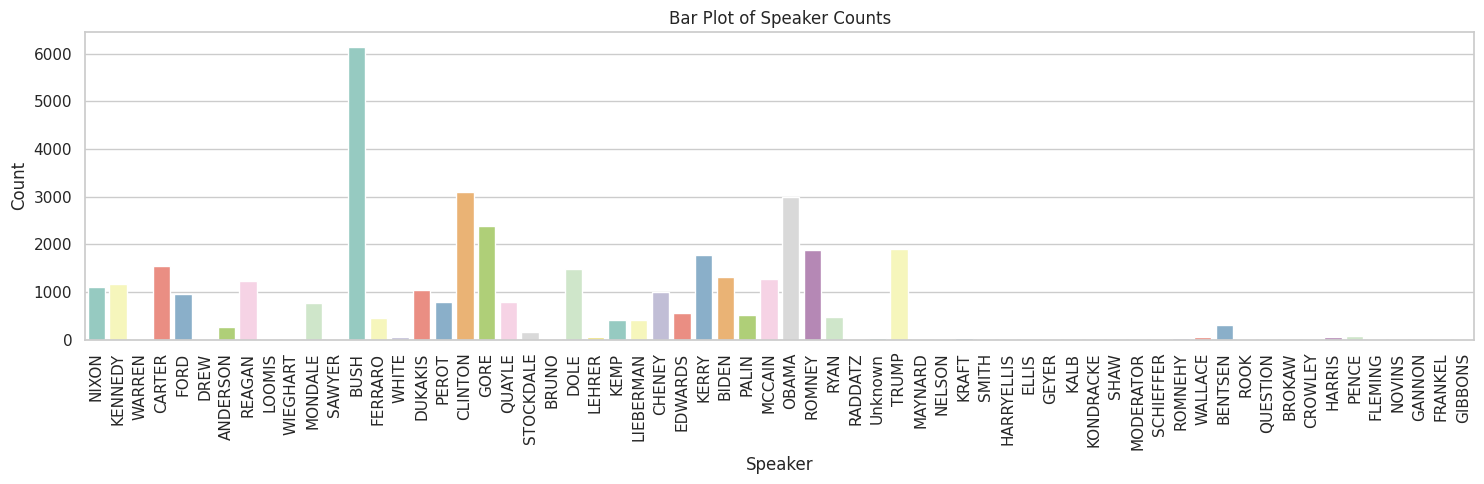

In [16]:
sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))
sns.countplot(data=nodes, x='speaker', palette='Set3')
plt.xlabel("Speaker")
plt.ylabel("Count")
plt.title("Bar Plot of Speaker Counts")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [17]:
# more claims than premises
nodes['type'].value_counts()

Claim      25078
Premise    13589
Name: type, dtype: int64

In [18]:
edges = get_edges(df)
edges.head()

,child,child_type,child_speaker,parent,parent_type,parent_speaker,relation
0,"As a matter of fact in his book, The Strategy ...",Claim,NIXON,For me to have made such a statement would bee...,Claim,NIXON,Support
1,"Now I'm very surprised that Senator Kennedy, w...",Claim,NIXON,"As a matter of fact in his book, The Strategy ...",Claim,NIXON,Support
2,"Now I'm very surprised that Senator Kennedy, w...",Premise,NIXON,Senator Kennedy also indicated with regard to ...,Claim,NIXON,Support
3,"I look at Cuba today, I believe that we are fo...",Claim,NIXON,We think that's pretty good progress,Claim,NIXON,Support
4,"I look at Cuba today, I believe that we are fo...",Premise,NIXON,a course which is difficult,Claim,NIXON,Attack


In [19]:
speeches_date = df['long_date'].unique().tolist()
print(speeches_date)
print(f'Num speeches: {len(speeches_date)}')

['07-10-1960', '26-09-1960', '23-09-1976', '21-09-1980', '07-10-1984', '11-10-1984', '25-09-1988', '11-10-1992', '13-10-1992', '06-10-1996', '09-10-1996', '03-10-2000', '05-10-2000', '05-10-2004', '30-09-2004', '02-10-2008', '26-09-2008', '03-10-2012', '11-10-2012', '09-10-2016', '26-09-2016', '21-10-1960', '22-10-1976', '28-10-1980', '21-10-1984', '13-10-1988', '15-10-1992', '16-10-1996', '17-10-2000', '13-10-2004', '15-10-2008', '22-10-2012', '19-10-2016', '13-10-1960', '06-10-1976', '05-10-1988', '19-10-1992', '11-10-2000', '08-10-2004', '07-10-2008', '16-10-2012', '22-10-2020', '07-10-2020', '29-09-2020']
Num speeches: 44


In [20]:
len_speeches = {}
for date in speeches_date:
  len_speeches[date] = len(df[df['long_date'] == date])

len_speeches = dict(sorted(len_speeches.items(), key = lambda x:datetime.strptime(x[0], '%d-%m-%Y')))
len_speeches

{'26-09-1960': 316,
 '07-10-1960': 450,
 '13-10-1960': 477,
 '21-10-1960': 345,
 '23-09-1976': 433,
 '06-10-1976': 644,
 '22-10-1976': 658,
 '21-09-1980': 389,
 '28-10-1980': 380,
 '07-10-1984': 470,
 '11-10-1984': 732,
 '21-10-1984': 517,
 '25-09-1988': 1027,
 '05-10-1988': 425,
 '13-10-1988': 489,
 '11-10-1992': 602,
 '13-10-1992': 810,
 '15-10-1992': 491,
 '19-10-1992': 632,
 '06-10-1996': 1002,
 '09-10-1996': 513,
 '16-10-1996': 769,
 '03-10-2000': 862,
 '05-10-2000': 601,
 '11-10-2000': 732,
 '17-10-2000': 787,
 '30-09-2004': 756,
 '05-10-2004': 770,
 '08-10-2004': 1026,
 '13-10-2004': 596,
 '26-09-2008': 672,
 '02-10-2008': 680,
 '07-10-2008': 655,
 '15-10-2008': 383,
 '03-10-2012': 746,
 '11-10-2012': 570,
 '16-10-2012': 731,
 '22-10-2012': 839,
 '26-09-2016': 696,
 '09-10-2016': 627,
 '19-10-2016': 295,
 '29-09-2020': 327,
 '07-10-2020': 77,
 '22-10-2020': 231}

In [21]:
max_key = max(len_speeches, key=lambda key: len_speeches[key])
min_key = min(len_speeches, key=lambda key: len_speeches[key])

print(f'Longest debate is {max_key} with {len_speeches[max_key]} nodes')
print(f'Shortest debate is {min_key} with {len_speeches[min_key]} nodes')

Longest debate is 25-09-1988 with 1027 nodes
Shortest debate is 07-10-2020 with 77 nodes


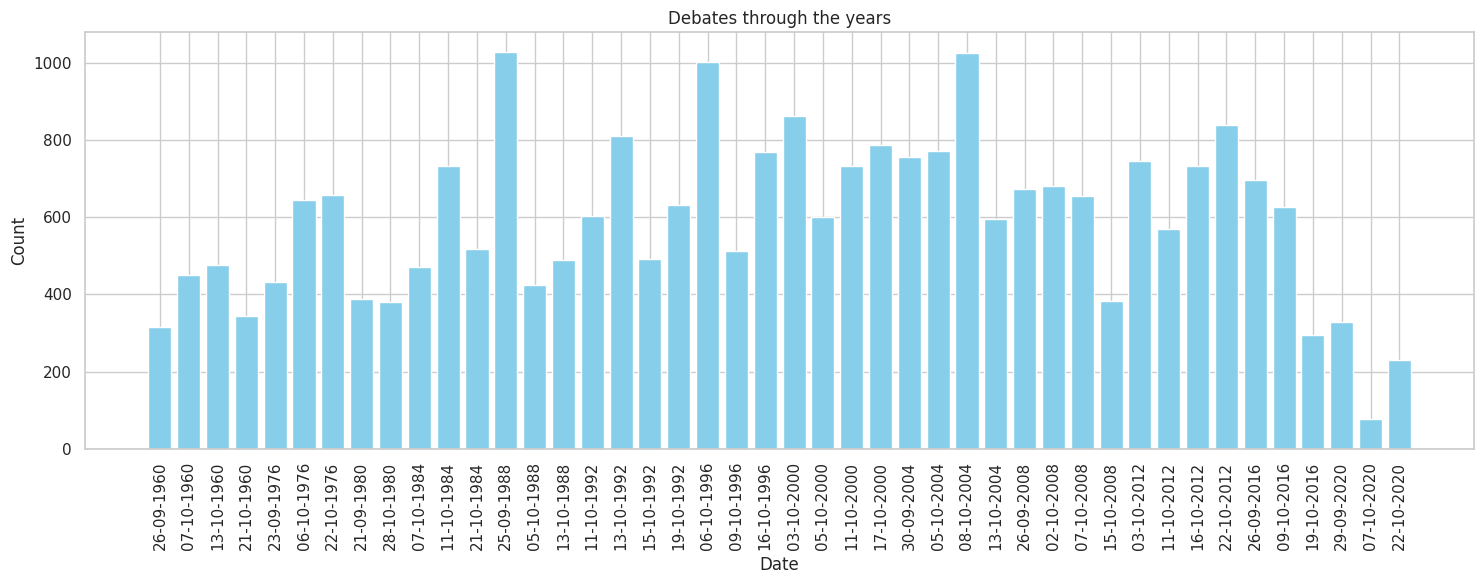

In [22]:
plt.figure(figsize=(15, 6))
plt.bar(len_speeches.keys(), len_speeches.values(), color='skyblue')
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Debates through the years")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [24]:
winners = {
  '07-10-1960': 'KENNEDY',
  '26-09-1960': 'KENNEDY',
  '23-09-1976': 'CARTER',
  '21-09-1980': 'REAGAN',
  '07-10-1984': 'REAGAN',
  '11-10-1984': 'REAGAN',
  '25-09-1988': 'BUSH',
  '11-10-1992': 'CLINTON',
  '13-10-1992': 'CLINTON',
  '06-10-1996': 'CLINTON',
  '09-10-1996': 'CLINTON',
  '03-10-2000': 'BUSH',
  '05-10-2000': 'BUSH',
  '05-10-2004': 'BUSH',
  '30-09-2004': 'BUSH',
  '02-10-2008': 'OBAMA',
  '26-09-2008': 'OBAMA',
  '03-10-2012': 'OBAMA',
  '11-10-2012': 'OBAMA',
  '09-10-2016': 'TRUMP',
  '26-09-2016': 'TRUMP',
  '21-10-1960': 'KENNEDY',
  '22-10-1976': 'CARTER',
  '28-10-1980': 'REAGAN',
  '21-10-1984': 'REAGAN',
  '13-10-1988': 'BUSH',
  '15-10-1992': 'CLINTON',
  '16-10-1996': 'CLINTON',
  '17-10-2000': 'BUSH',
  '13-10-2004': 'BUSH',
  '15-10-2008': 'OBAMA',
  '22-10-2012': 'OBAMA',
  '19-10-2016': 'TRUMP',
  '13-10-1960': 'KENNEDY',
  '06-10-1976': 'CARTER',
  '05-10-1988': 'BUSH',
  '19-10-1992': 'CLINTON',
  '11-10-2000': 'BUSH',
  '08-10-2004': 'BUSH',
  '07-10-2008': 'OBAMA',
  '16-10-2012': 'OBAMA',
  '22-10-2020': 'BIDEN',
  '07-10-2020': 'BIDEN',
  '29-09-2020': 'BIDEN'}

df['winner'] =  df['long_date'].map(winners)

In [25]:
df['winner'].value_counts()

BUSH       8071
OBAMA      5276
CLINTON    4819
REAGAN     2488
CARTER     1735
TRUMP      1618
KENNEDY    1588
BIDEN       635
Name: winner, dtype: int64

In [32]:
# How many times they were elected
mean_claim_winners = []
for winner in df['winner'].value_counts().index:
  df_winner = df[df['winner']==winner].drop_duplicates()
  n_of_wins = len(df_winner['Year'].unique())

  nodes = get_nodes(df_winner)
  claims = nodes[nodes['type']== 'Claim']
  premises = nodes[nodes['type']== 'Premise']
  print(f'{winner} has won {n_of_wins} times with {len(claims)} claims and {len(premises)} premises')

  mean_claim_winners.append(len(claims))

  print(f'Claims are {len(claims)/(len(nodes))*100:.2f}% of the total')
  print(f'Premises are {len(premises)/(len(nodes))*100:.2f}% of the total\n')

  edges = get_edges(df_winner)
  edges = edges[edges['parent_speaker']==winner]['relation']

  stat = edges.value_counts()
  print(f'{stat}\n')

  for i in range(len(stat)):
    print(f'{stat.index[i]} relations are {stat.values[i]/sum(stat.values)*100:.2f}% of total')

  print("----------------------------------------------------")
  print("\n\n")

BUSH has won 3 times with 7728 claims and 3956 premises
Claims are 66.14% of the total
Premises are 33.86% of the total

Support       2656
Attack         544
Equivalent      49
Name: relation, dtype: int64

Support relations are 81.75% of total
Attack relations are 16.74% of total
Equivalent relations are 1.51% of total
----------------------------------------------------



OBAMA has won 2 times with 5081 claims and 3003 premises
Claims are 62.85% of the total
Premises are 37.15% of the total

Support       1675
Attack         222
Equivalent      13
Name: relation, dtype: int64

Support relations are 87.70% of total
Attack relations are 11.62% of total
Equivalent relations are 0.68% of total
----------------------------------------------------



CLINTON has won 2 times with 4657 claims and 2548 premises
Claims are 64.64% of the total
Premises are 35.36% of the total

Support       1179
Attack         144
Equivalent      27
Name: relation, dtype: int64

Support relations are 87.33% o

In [33]:
# how the losers were doing
losers = set(get_nodes(df)['speaker'].unique()) - set(df['winner'].unique())
mean_claim_losers = []

for loser in losers:
  df_loser = df[(df['Speaker1']==loser) | (df['Speaker2']==loser)].drop_duplicates()

  n_of_losses = len(df_loser['Year'].unique())

  nodes = get_nodes(df_loser)

  claims = nodes[nodes['type']== 'Claim']
  premises = nodes[nodes['type']== 'Premise']
  print(f'{loser} has lost {n_of_losses} times with {len(claims)} claims and {len(premises)} premises')

  mean_claim_losers.append(len(claims))

  print(f'Claims are {len(claims)/(len(nodes))*100:.2f}% of the total')
  print(f'Premises are {len(premises)/(len(nodes))*100:.2f}% of the total\n')

  edges = get_edges(df_loser)
  edges = edges[edges['parent_speaker'] == loser]['relation']
  stat = edges.value_counts()
  print(f'{stat}\n')

  for i in range(len(stat)):
    print(f'{stat.index[i]} relations are {stat.values[i]/sum(stat.values)*100:.2f}% of total')

  print("----------------------------------------------------")
  print("\n\n")

CROWLEY has lost 1 times with 3 claims and 2 premises
Claims are 60.00% of the total
Premises are 40.00% of the total

Support    3
Name: relation, dtype: int64

Support relations are 100.00% of total
----------------------------------------------------



ROOK has lost 1 times with 6 claims and 2 premises
Claims are 75.00% of the total
Premises are 25.00% of the total

Attack     2
Support    1
Name: relation, dtype: int64

Attack relations are 66.67% of total
Support relations are 33.33% of total
----------------------------------------------------



KEMP has lost 1 times with 318 claims and 155 premises
Claims are 67.23% of the total
Premises are 32.77% of the total

Support       213
Attack         54
Equivalent      4
Name: relation, dtype: int64

Support relations are 78.60% of total
Attack relations are 19.93% of total
Equivalent relations are 1.48% of total
----------------------------------------------------



ROMNEY has lost 1 times with 1195 claims and 728 premises
Claims 

In [36]:
print(f'Average claim per winner: {np.mean(mean_claim_winners)}')
print(f'Average claim per loser: {np.mean(mean_claim_losers)}')

Average claim per winner: 3135.75
Average claim per loser: 239.25


In [204]:
for loser in losers:
  df_loser = df[(df['Speaker1']==loser) | (df['Speaker2']==loser)].drop_duplicates()

  n_of_losses = len(df_loser['Year'].unique())

  nodes = get_nodes(df_loser)
  nodes = nodes[nodes['speaker'] == loser]

  claims = nodes[nodes['type']== 'Claim']
  premises = nodes[nodes['type']== 'Premise']
  print(f'{loser} has lost {n_of_losses} times with {len(claims)} claims and {len(premises)} premises')

  print(f'Claims are {len(claims)/(len(nodes))*100:.2f}% of the total')
  print(f'Premises are {len(premises)/(len(nodes))*100:.2f}% of the total\n')

  edges = get_edges(df_loser)
  print(edges)
  break

MCCAIN has lost 1 times with 854 claims and 408 premises
Claims are 67.67% of the total
Premises are 32.33% of the total

                                                 node1    type1 speaker1  \
0    the fact is that it was $3 million of our taxp...  Premise   MCCAIN   
1                       It's completely out of control    Claim   MCCAIN   
2                       It's completely out of control  Premise   MCCAIN   
3                       It's completely out of control  Premise   MCCAIN   
4                       It's completely out of control    Claim   MCCAIN   
..                                                 ...      ...      ...   
855                I know what it's like in dark times  Premise   MCCAIN   
856                I know what it's like in dark times  Premise   MCCAIN   
857                I know what it's like in dark times    Claim   MCCAIN   
858                I know what it's like in dark times    Claim   MCCAIN   
859                I know what it's like i

## Visualization

In [147]:
# generate a df per debate
deb_list = []
for date in speeches:
  deb = df[df['long_date']==str(date)].copy()
  deb = deb.drop(labels=['Year', 'date'], axis=1).reset_index(drop=True)
  deb_list.append(deb)

In [148]:
deb_list[10].head()

,Dependent,D_type,Speaker1,Governor,G_type,Speaker2,RelationType,long_date,winner
0,This is the greatest democracy in the world,Premise,KEMP,This is a democracy in which we have the frees...,Claim,KEMP,Support,09-10-1996,CLINTON
1,I really got only two differences with Bill Cl...,Claim,KEMP,"Our foreign policy is ambivalent, confusing, i...",Claim,KEMP,Support,09-10-1996,CLINTON
2,"Our foreign policy is ambivalent, confusing, i...",Premise,KEMP,we have learned over the years that weakness i...,Claim,KEMP,Support,09-10-1996,CLINTON
3,Bob Dole and I believe we can do a lot better,Claim,KEMP,domestic economy is not doing what it can do,Claim,KEMP,Support,09-10-1996,CLINTON
4,Bob Dole and I believe we can do a lot better,Premise,KEMP,It is about the potential of the American peop...,Claim,KEMP,Support,09-10-1996,CLINTON


In [149]:
adj, node_labels, node_text, node_speaker = get_adj_matrix_and_labels(deb_list[10])

  0%|          | 0/784 [00:00<?, ?it/s]

In [150]:
fig  = plot_graph(adj, node_labels, node_text, node_speaker)
plt.tight_layout()
fig.show()

Claim: yellow, Premise: purle
Equivalent relation: blue, Support: green, Attack:red


<Figure size 640x480 with 0 Axes>

In [15]:
fig.write_image("09-10-1996_debate_graph.svg")